# Pandas: Merge DataFrame
**Method**
- df.merge()

In [51]:
#Import Libraries
from datasets import load_dataset as ld
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
raw = ld('lukebarousse/data_jobs')
df_original = raw['train'].to_pandas()
df = df_original.copy()

# Date Conversion 
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


*US Job Demand Pivot*

In [52]:
df['job_posted_month']=df['job_posted_date'].dt.strftime('%B') 
df_US = df.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size')

In [53]:
df_US

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,4246,1051,15514,14891,13513,990,2351,3572,2766,4025
August,5189,1378,18628,15622,16984,1360,2951,4025,4055,4970
December,4038,1152,13583,13303,12024,1254,1799,2878,2431,3841
February,3454,843,16558,15899,13951,1046,2713,3756,2994,3364
January,4874,1295,23585,21419,20760,1386,3696,5041,4644,5122
July,3850,1059,16095,14518,14177,1174,2380,3744,3117,3663
June,3413,714,16008,15501,13615,1048,2319,3809,2932,2213
March,3393,883,16243,16093,13569,1065,2454,3705,2987,3692
May,2408,480,13423,13646,11745,811,1925,3298,2399,1969


In [54]:
df_US.reset_index(inplace=True)

In [55]:
df_US['Month_no']=pd.to_datetime(df_US['job_posted_month'],format='%B').dt.month
df_US.sort_values('Month_no',inplace=True)
df_US.drop('Month_no',axis=1,inplace=True)
df_US.set_index('job_posted_month',inplace=True)
df_US

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,4874,1295,23585,21419,20760,1386,3696,5041,4644,5122
February,3454,843,16558,15899,13951,1046,2713,3756,2994,3364
March,3393,883,16243,16093,13569,1065,2454,3705,2987,3692
April,4246,1051,15514,14891,13513,990,2351,3572,2766,4025
May,2408,480,13423,13646,11745,811,1925,3298,2399,1969
June,3413,714,16008,15501,13615,1048,2319,3809,2932,2213
July,3850,1059,16095,14518,14177,1174,2380,3744,3117,3663
August,5189,1378,18628,15622,16984,1360,2951,4025,4055,4970
September,4447,1022,14969,14918,13577,1250,2194,3547,2936,3499


In [56]:
top3 = (df['job_title_short']
        .value_counts()
        .head(3)
        .index
        .to_list())
top3

['Data Analyst', 'Data Engineer', 'Data Scientist']

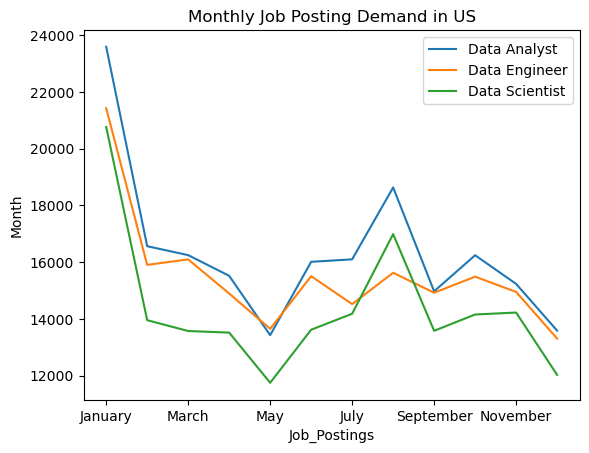

In [57]:
df_US[top3].plot(kind='line')
plt.legend()
plt.title('Monthly Job Posting Demand in US')
plt.xlabel('Job_Postings')
plt.ylabel('Month')
plt.show()

In [58]:
df_US_Pivot= df_US[top3]
df_US_Pivot

job_title_short,Data Analyst,Data Engineer,Data Scientist
job_posted_month,,,
January,23585,21419,20760
February,16558,15899,13951
March,16243,16093,13569
April,15514,14891,13513
May,13423,13646,11745
June,16008,15501,13615
July,16095,14518,14177
August,18628,15622,16984
September,14969,14918,13577


In [ ]:
US_software_Pivot =pd.read_csv(r"C:\Users\rishi\Downloads\software_jobs.csv")
US_software_Pivot.set_index('job_posted_month',inplace=True)
US_software_Pivot

# Note:
# if the  Dataframe have different format for job_posted_month column like 'Jan', but the other Dataframe have like 'January',
# so Dataframe can't get merge . 
# for to merge we need to change the format of any one dataframe to match the other dataframe, then only we can merge 

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


**df.merge() Method**

*Now we are going to merge the above 2 tables*

In [60]:
df_US_Merge=df_US_Pivot.merge(US_software_Pivot,on='job_posted_month')

In [66]:
top5_jobs =(df_US_Merge
            .sum()
            .head(5)
            .index
            .to_list())
top5_jobs

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Front-End Developer',
 'Back-End Developer']

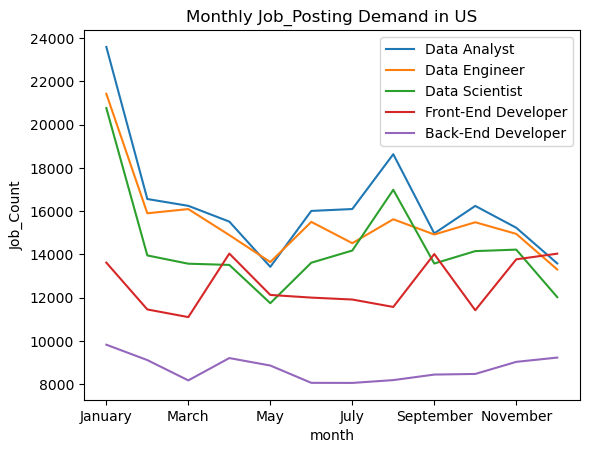

In [68]:
df_US_Merge[top5_jobs].plot(kind='line')
plt.xlabel('month')
plt.ylabel('Job_Count')
plt.title('Monthly Job_Posting Demand in US')
plt.show()